In [1]:
import os
import sys
import json
import itertools
import pandas as pd
import torch
from PIL import Image
from diffusers.utils import make_image_grid
from IPython.display import display, clear_output
from transformers import CLIPTextModel, T5EncoderModel, BitsAndBytesConfig
from diffusers import AutoencoderKL
from diffusers.models import FluxTransformer2DModel

/tmp/eoikonom/Thesis/venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/eoikonom/Thesis/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
os.chdir("../..")

# Now all shared paths work consistently across all repos!
DATASET_DIR = "./datasets/test_images"
OUTPUT_DIR  = "./outputs/slideredit/gstlora"
CSV_PATH    = "./SliderEdit/experiments/experiments24-7.csv"

In [3]:
sys.path.append("./SliderEdit")

from slideredit.pipelines import SliderEditFluxKontextPipeline
from slideredit.pipelines import LoRAAdapterType

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Name: NVIDIA GeForce RTX 4090


## HuggingFace

In [4]:
from huggingface_hub import login

token_path = "/cs/student/msc/ml/2025/eoikonom/.hf_token"
if os.path.exists(token_path):
    with open(token_path, "r") as f:
        login(token=f.read().strip())

# Load FLUX

In [5]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

MODEL_ID = "black-forest-labs/FLUX.1-Kontext-dev"

# Load heavy text encoders straight to GPU in bfloat16
clip_text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=torch.bfloat16).to("cuda")
t5_text_encoder = T5EncoderModel.from_pretrained(MODEL_ID, subfolder="text_encoder_2", torch_dtype=torch.bfloat16).to("cuda")
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae").to("cuda", dtype=torch.bfloat16)

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=quantization_config,
    device_map={"": "cuda"}
)

print("🔌 Assembling the SliderEdit Pipeline...")
pipe = SliderEditFluxKontextPipeline.from_pretrained(
    MODEL_ID,
    vae=vae,
    text_encoder=clip_text_encoder,
    text_encoder_2=t5_text_encoder,
    transformer=transformer,
    torch_dtype=torch.bfloat16
)

print(f"Loaded {MODEL_ID} successfully!")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.12s/it]


🔌 Assembling the SliderEdit Pipeline...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 67.10it/s]

Loaded black-forest-labs/FLUX.1-Kontext-dev successfully!


### Load CSV

In [8]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find {CSV_PATH}.")

df_experiments = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df_experiments)} experiments from {CSV_PATH}\n")
display(df_experiments[["id", "domain", "subprompt_1", "subprompt_2", "test_focus"]].head(10))

Loaded 20 experiments from ./SliderEdit/experiments/experiments24-7.csv



,id,domain,subprompt_1,subprompt_2,test_focus
0,typo_01,Typography,"change the font style of the word ""THESIS"" to ...",increase the letter outline stroke thickness o...,Geometric continuity and sharp edge preservation
1,typo_02,Typography,increase the neon glass tube stroke thickness ...,increase the brightness and intensity of the g...,Local geometry vs global illumination disentan...
2,typo_03,Typography,"apply an italic slant angle to the letter ""A""",add ornamental decorative flourishes to the le...,Shear and affine transformation monotonicity
3,typo_04,Typography,"change the font style of the word ""DESIGN"" to ...","extrude the letters of the word ""DESIGN"" into ...",Complex typographic style transition and depth...
4,typo_05,Typography,increase the horizontal kerning and spacing be...,add a subtle dark drop shadow underneath the t...,Kerning and spatial separation vs shadow casting
5,fashion_01,Fashion,change the t-shirt material to blue denim fabric,change the t-shirt fit to an oversized relaxed...,Texture vs silhouette disentanglement
6,fashion_02,Fashion,extend the length of the blazer lower hem line,add polished decorative gold buttons down the ...,Boundary and occlusion continuity
7,fashion_03,Fashion,extend the shoe collar height into a high-top ...,increase the bottom sole thickness into a thic...,Structural deformations and proportion scaling
8,fashion_04,Fashion,change the dress material to glossy silk satin...,apply an intricate floral print pattern across...,Surface reflectivity vs complex pattern overlay
9,fashion_05,Fashion,add a black leather jacket layered over the t-...,add distressed ripped details and tears to the...,Layering addition vs local material destruction


### Run Experiments Function Using CSV

In [ ]:
def run_benchmark_suite(
    df, 
    pipe, 
    mode="gstlora",  # 'gstlora' (1D single slider) or 'stlora' (2D grid)
    checkpoint_path="./SliderEdit/checkpoints/example_training_gstlora_iter500.safetensors",
    alpha_steps=[1.0, 0.5, 0.0, -0.5, -1.0],
    output_root="./outputs/slideredit",
    source_img_dir="./datasets/test_images"
):
    """
    Iterates through the benchmark DataFrame, generates pure FLUX base source images
    with LoRA unhooked, runs 1D (gSTLoRA) or 2D (STLoRA) sweeps with LoRA re-hooked,
    saves metadata, and outputs image grids.
    """
    # -------------------------------------------------------------------------
    # 1. Resolve Absolute Paths (Prevents lost output files)
    # -------------------------------------------------------------------------
    source_img_dir_abs = os.path.abspath(source_img_dir)
    mode_output_dir_abs = os.path.abspath(os.path.join(output_root, mode))

    os.makedirs(source_img_dir_abs, exist_ok=True)
    os.makedirs(mode_output_dir_abs, exist_ok=True)

    if mode == "gstlora":
        pipe.load_gstlora(checkpoint_path)
        pipe.loaded_adapter = LoRAAdapterType.GSTLORA
    elif mode == "stlora":
        pipe.load_stlora(checkpoint_path, lora_rank=16, lora_dropout=0.0)
        pipe.loaded_adapter = LoRAAdapterType.STLORA

    print(f"==================================================")
    print(f"  STARTING BENCHMARK RUN: {mode.upper()}")
    print(f"  Checkpoint: {checkpoint_path}")
    print(f"  Alpha Range: {alpha_steps}")
    print(f"  Output Folder: {mode_output_dir_abs}")
    print(f"==================================================\n")

    for idx, row in df.iterrows():
        sweep_id = str(row['id'])
        subprompt1 = str(row['subprompt_1'])
        subprompt2 = str(row['subprompt_2'])
        seed = int(row['seed'])
        base_prompt = str(row['base_prompt'])
        test_focus = str(row['test_focus'])

        exp_dir = os.path.join(mode_output_dir_abs, sweep_id)
        os.makedirs(exp_dir, exist_ok=True)

        # ----------------------------------------------------------------------
        # Step A: Base Source Image (Unhook LoRA -> Generate Pure FLUX -> Re-hook)
        # ----------------------------------------------------------------------
        source_img_path = os.path.join(source_img_dir_abs, f"{sweep_id}.png")
        if os.path.exists(source_img_path):
            img = Image.open(source_img_path).convert("RGB")
        else:
            print(f"[{sweep_id}] Source image missing. Unhooking adapter for pure FLUX base generation...")

            # 1. Unhook adapter state to force native FLUX super().__call__
            pipe.loaded_adapter = LoRAAdapterType.NONE

            # 2. Generate pure un-adapted base image
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                img = pipe(
                    prompt=base_prompt,
                    generator=torch.Generator(device="cuda").manual_seed(seed)
                ).images[0]
                
            img.save(source_img_path)
            print(f"Saved pure base image to {source_img_path}")

            # 3. Re-hook adapter for the upcoming editing sweep
            if mode == "gstlora":
                pipe.load_gstlora(checkpoint_path)
                pipe.loaded_adapter = LoRAAdapterType.GSTLORA
            elif mode == "stlora":
                pipe.load_stlora(checkpoint_path, lora_rank=16, lora_dropout=0.0)
                pipe.loaded_adapter = LoRAAdapterType.STLORA

        # ----------------------------------------------------------------------
        # Step B: Save Metadata
        # ----------------------------------------------------------------------
        meta_data = {
            "id": sweep_id,
            "domain": row['domain'],
            "mode": mode,
            "base_prompt": base_prompt,
            "subprompt_1": subprompt1,
            "subprompt_2": subprompt2,
            "seed": seed,
            "alpha_steps": alpha_steps,
            "test_focus": test_focus
        }
        with open(os.path.join(exp_dir, "meta.json"), "w") as f:
            json.dump(meta_data, f, indent=4)

        # ----------------------------------------------------------------------
        # Step C: Run Inference Sweeps
        # ----------------------------------------------------------------------
        outputs = []

        if mode == "gstlora":
            # --- 1D Single Slider Sweep ---
            edit_prompt = subprompt1
            print(f"[{idx+1}/{len(df)}] Running 1D Sweep '{sweep_id}': '{edit_prompt}'")

            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                for a in alpha_steps:
                    out_img = pipe(
                        image=img,
                        prompt=edit_prompt,
                        generator=torch.Generator(device="cuda").manual_seed(seed),
                        slider_alpha=a
                    ).images[0]

                    clean_prompt = "".join(c for c in edit_prompt if c.isalnum() or c in (" ", "_")).replace(" ", "_")
                    alpha_str = f"{a:.2f}".replace("-", "neg_")
                    fname = f"{sweep_id}_{clean_prompt}_alpha_{alpha_str}.png"
                    
                    save_path = os.path.join(exp_dir, fname)
                    out_img.save(save_path)
                    outputs.append(out_img)

            # Display 1D Grid
            clear_output(wait=True)
            print(f"Completed [{sweep_id}] - Focus: {test_focus}")
            grid = make_image_grid([x.resize((128, 128)) for x in outputs], rows=1, cols=len(alpha_steps))
            display(grid)

        elif mode == "stlora":
            # --- 2D Multi Slider Sweep ---
            subprompts_list = [subprompt1, subprompt2]
            combined_edit_prompt = f"{subprompt1} and {subprompt2}"
            alpha_pairs = list(itertools.product(alpha_steps, repeat=2))
            
            print(f"[{idx+1}/{len(df)}] Running 2D Grid '{sweep_id}'")
            print(f" -> Edit Instruction: '{combined_edit_prompt}'")

            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                for a1, a2 in alpha_pairs:
                    out_img = pipe(
                        image=img,
                        prompt=combined_edit_prompt,
                        generator=torch.Generator(device="cuda").manual_seed(seed),
                        subprompts_list=subprompts_list,
                        slider_alpha_list=[a1, a2]
                    ).images[0]

                    clean1 = "".join(c for c in subprompt1 if c.isalnum() or c in (" ", "_")).replace(" ", "_")
                    clean2 = "".join(c for c in subprompt2 if c.isalnum() or c in (" ", "_")).replace(" ", "_")
                    a1_str, a2_str = f"{a1:.2f}".replace("-", "neg_"), f"{a2:.2f}".replace("-", "neg_")
                    
                    fname = f"{sweep_id}_{clean1}_{a1_str}_{clean2}_{a2_str}.png"
                    save_path = os.path.join(exp_dir, fname)
                    out_img.save(save_path)
                    outputs.append(out_img)

            # Display 2D Grid
            clear_output(wait=True)
            print(f"Completed [{sweep_id}] - Focus: {test_focus}")
            grid = make_image_grid([x.resize((128, 128)) for x in outputs], rows=len(alpha_steps), cols=len(alpha_steps))
            display(grid)

        # Cleanup memory after each experiment
        del outputs
        del grid
        torch.cuda.empty_cache()

    print("\nBenchmark Run Complete!")

### GSTLoRA

Completed [typo_01] - Focus: Geometric continuity and sharp edge preservation


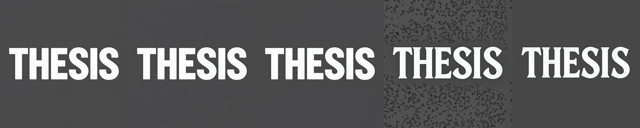

[typo_02] Source image missing. Generating base image from prompt...


100%|██████████| 28/28 [00:26<00:00,  1.04it/s]


Saved base image to ./datasets/test_images/typo_02.png

[2/20] Running 1D gSTLoRA Sweep 'typo_02': 'increase the neon glass tube stroke thickness of the sign'


  0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:
# reverse direction for better visualization of edits (1.0 = full suppression, 0.0 = full edit)
SWEEP_ALPHAS = [1.0, 0.5, 0.0, -0.5, -1.0]

run_benchmark_suite(
    df=df_experiments, 
    pipe=pipe, 
    mode="gstlora", 
    checkpoint_path="./SliderEdit/checkpoints/example_training_gstlora_iter500.safetensors",
    alpha_steps=SWEEP_ALPHAS
)

### STLoRA

Completed [scene_02] - Focus: Surface reflection physics vs localized light source addition


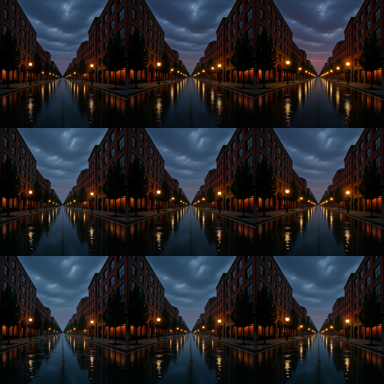

[9/10] Running 2D Grid 'scene_03'
 -> Edit Instruction: 'cover the landscape in a thick layer of winter snow and add dense atmospheric fog throughout the forest background'


 43%|████▎     | 12/28 [00:20<00:28,  1.75s/it]

In [ ]:
GRID_ALPHAS = [1.0, 0.0, -1.0]

# only use specific examples for 2D grid testing to reduce runtime and memory usage
STLORA_ILOC_INDICES = [4, 5, 7, 11, 13, 16, 17, 18, 19, 1] # 1 at the end because edits are minor and its hard to use for debugging
df_2d = df_experiments.iloc[STLORA_ILOC_INDICES].reset_index(drop=True)

run_benchmark_suite(
    df=df_2d, 
    pipe=pipe, 
    mode="stlora", 
    checkpoint_path="./SliderEdit/checkpoints/example_training_stlora_iter1200.pt",
    alpha_steps=GRID_ALPHAS
)

### Debug STLoRA Pipeline Logic (IGNORE)

In [19]:
import numpy as np
from PIL import Image

class MockFluxPipeline:
    def __init__(self):
        self.loaded_adapter = "NONE"
        
    def load_gstlora(self, path):
        print(f"   [Mock Pipe] Called load_gstlora('{path}')")
        
    def load_stlora(self, path, **kwargs):
        print(f"   [Mock Pipe] Called load_stlora('{path}')")

    def __call__(self, prompt=None, image=None, slider_alpha=None, slider_alpha_list=None, subprompts_list=None, generator=None):
        # Convert adapter state to string safely (handles both Enums and Strings)
        adapter_str = str(self.loaded_adapter).upper()
        
        if "NONE" in adapter_str:
            print(f"   --> Executing BASE generation (Adapter: {adapter_str})")
            img_array = np.full((128, 128, 3), 128, dtype=np.uint8) # Neutral Gray
            
        elif "GSTLORA" in adapter_str:
            a = slider_alpha if slider_alpha is not None else 0.0
            val = int(128 + a * 50)
            val = max(0, min(255, val))
            print(f"   --> Executing gSTLoRA (Alpha={a}, Active Adapter={adapter_str})")
            img_array = np.full((128, 128, 3), [val, 0, 0], dtype=np.uint8) # Red Shift
            
        elif "STLORA" in adapter_str:
            a1, a2 = slider_alpha_list if slider_alpha_list is not None else (0.0, 0.0)
            val1 = max(0, min(255, int(128 + a1 * 50)))
            val2 = max(0, min(255, int(128 + a2 * 50)))
            print(f"   --> Executing STLoRA (Alphas=[{a1}, {a2}], Prompt='{prompt}', Adapter={adapter_str})")
            img_array = np.full((128, 128, 3), [val1, val2, 0], dtype=np.uint8) # Red/Green Shift
            
        else:
            # Safe Fallback
            print(f"   --> Fallback execution (Unknown Adapter state: {adapter_str})")
            img_array = np.full((128, 128, 3), 200, dtype=np.uint8)

        # Return fake output structure mimicking Hugging Face Diffusers
        class FakeOutput:
            def __init__(self, img):
                self.images = [Image.fromarray(img)]
                
        return FakeOutput(img_array)

Completed [typo_02] - Focus: Local geometry vs global illumination disentanglement


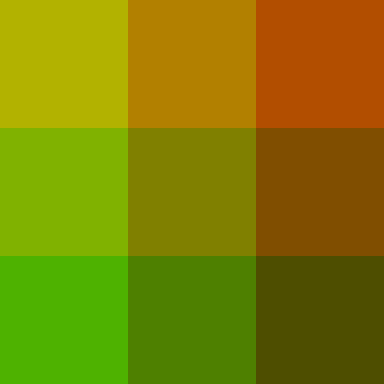


Benchmark Run Complete!


In [20]:
# Instantiate mock pipeline
mock_pipe = MockFluxPipeline()

# Test 2D STLoRA execution flow on first 2 rows of your CSV
run_benchmark_suite(
    df=df_experiments.iloc[:2], 
    pipe=mock_pipe, 
    mode="stlora", 
    checkpoint_path="./fake/path/stlora.safetensors",
    alpha_steps=[1.0, 0.0, -1.0],
    output_root="./test_outputs"
)